# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

## 1. Preprocessing and logreg visualization

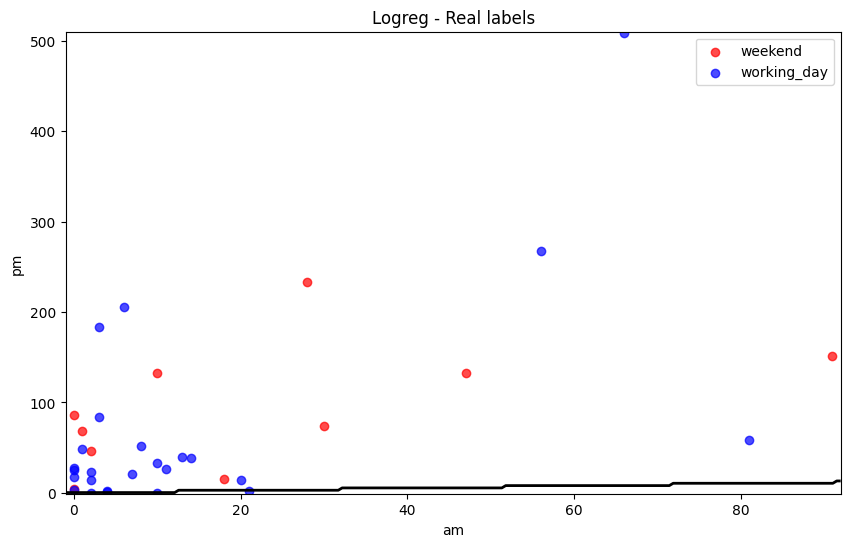

In [2]:
df = pd.read_csv('../data/am_pm.csv')
X = df[['am', 'pm']].values
y = df['target'].values

# Train logreg
logreg = LogisticRegression(random_state=21, fit_intercept=False)
logreg.fit(X, y)

def plot_decision_boundary(model, X, y_color_col, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {'working_day': 'blue', 'weekend': 'red'}
    
    # Plot points
    for label in np.unique(y_color_col):
        mask = y_color_col == label
        ax.scatter(X[mask, 0], X[mask, 1], label=label,
                   color=colors[label], alpha=0.7)
    
    # Decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z == 'working_day').reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    ax.set_xlabel('am')
    ax.set_ylabel('pm')
    ax.set_title(title)
    ax.legend()
    plt.show()

# Plot with real target colors
plot_decision_boundary(logreg, X, y, 'Logreg - Real labels')

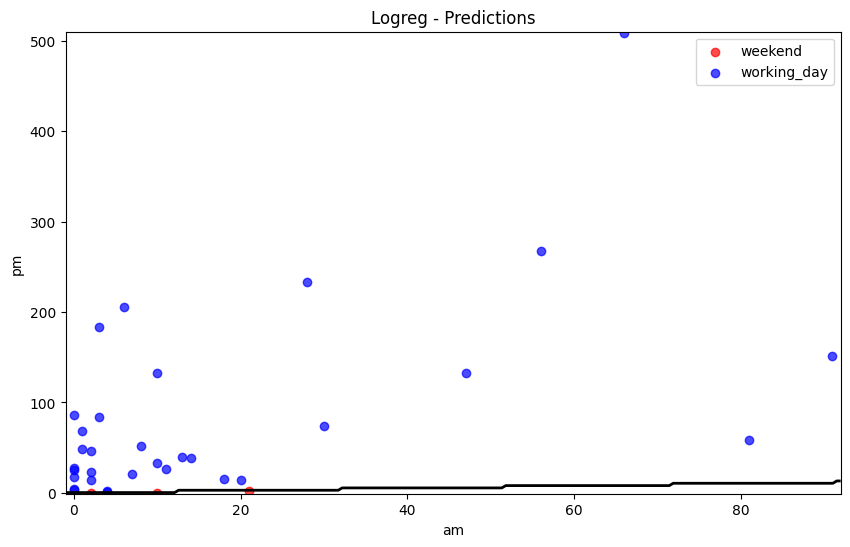

In [3]:
# Plot with predicted colors
plot_decision_boundary(logreg, X, logreg.predict(X), 'Logreg - Predictions')

## 2. Standardizing and logreg

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logreg_scaled = LogisticRegression(random_state=21, fit_intercept=False)
logreg_scaled.fit(X_scaled, y)

acc_scaled = accuracy_score(y, logreg_scaled.predict(X_scaled))
naive_acc = accuracy_score(y, ['working_day'] * len(y))
print(f'Scaled logreg accuracy: {acc_scaled:.4f}')
print(f'Naive accuracy: {naive_acc:.4f}')
print(f'Better than naive: {acc_scaled > naive_acc}')

Scaled logreg accuracy: 0.7429
Naive accuracy: 0.7143
Better than naive: True


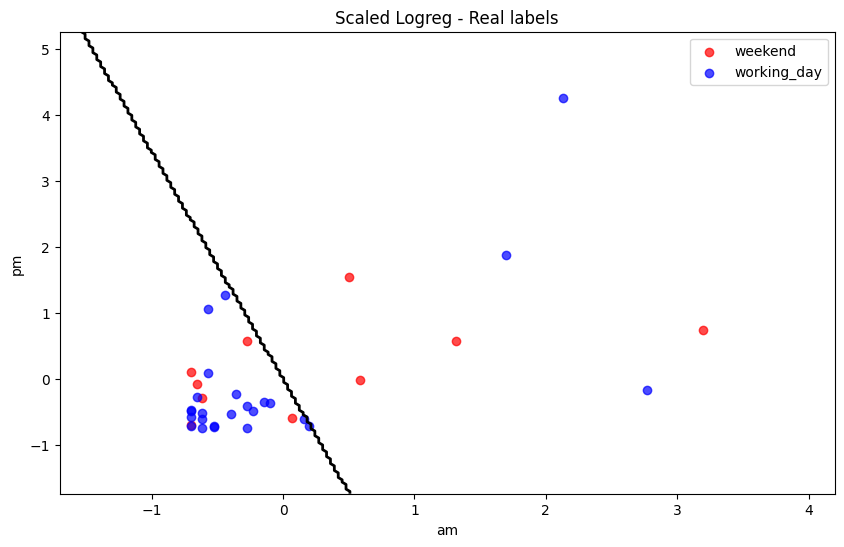

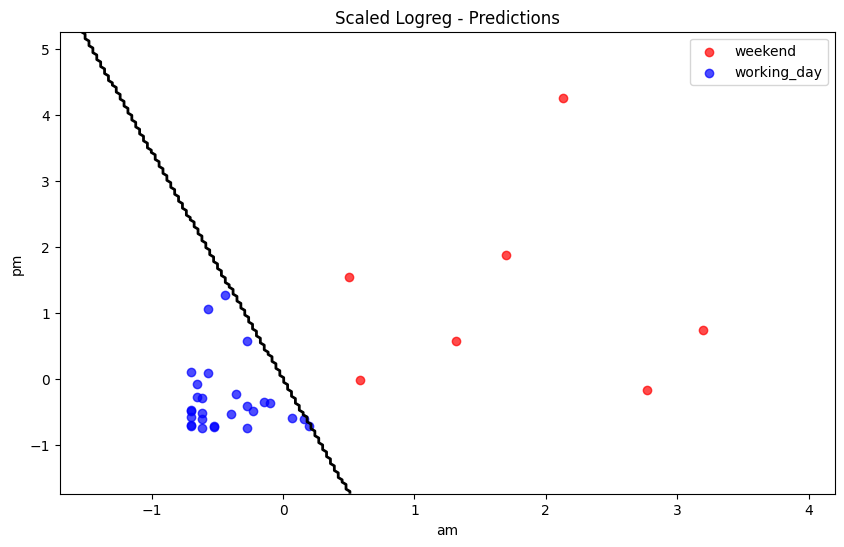

In [5]:
plot_decision_boundary(logreg_scaled, X_scaled, y, 'Scaled Logreg - Real labels')
plot_decision_boundary(logreg_scaled, X_scaled, logreg_scaled.predict(X_scaled), 'Scaled Logreg - Predictions')

## 3. SVM

In [6]:
# Try different kernels
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    svm = SVC(kernel=kernel, probability=True, random_state=21)
    svm.fit(X_scaled, y)
    acc = accuracy_score(y, svm.predict(X_scaled))
    print(f'SVM kernel={kernel}: accuracy={acc:.4f}')

SVM kernel=linear: accuracy=0.7143
SVM kernel=rbf: accuracy=0.7429
SVM kernel=poly: accuracy=0.7429
SVM kernel=sigmoid: accuracy=0.6857


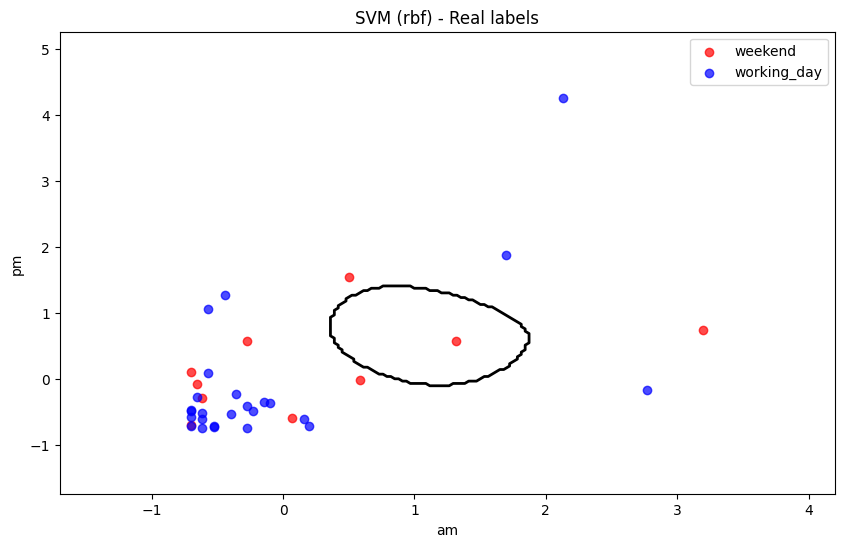

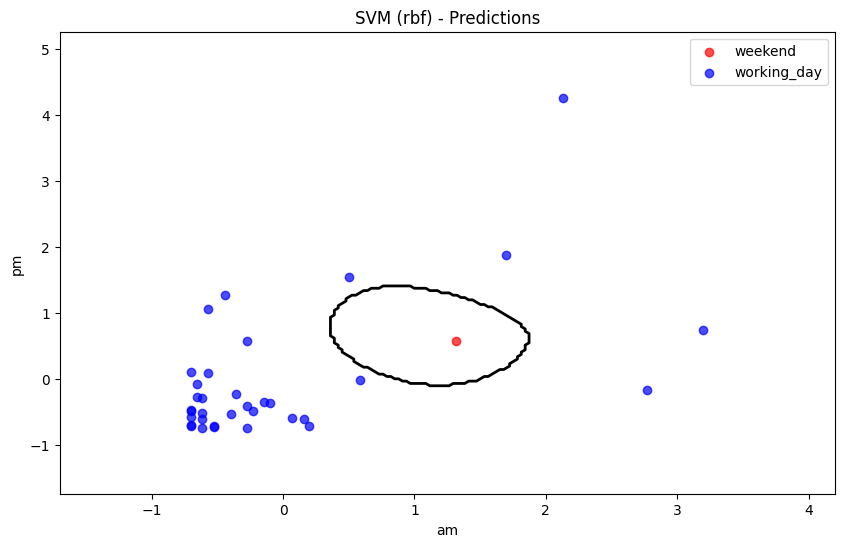

In [7]:
# Best SVM
svm_best = SVC(kernel='rbf', probability=True, random_state=21)
svm_best.fit(X_scaled, y)

plot_decision_boundary(svm_best, X_scaled, y, 'SVM (rbf) - Real labels')
plot_decision_boundary(svm_best, X_scaled, svm_best.predict(X_scaled), 'SVM (rbf) - Predictions')

## 4. Decision tree

In [8]:
# Try different max_depth
for depth in [2, 3, 4, 5, 6]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_scaled, y)
    acc = accuracy_score(y, tree.predict(X_scaled))
    print(f'Decision Tree max_depth={depth}: accuracy={acc:.4f}')

Decision Tree max_depth=2: accuracy=0.8571
Decision Tree max_depth=3: accuracy=0.8857
Decision Tree max_depth=4: accuracy=0.9429
Decision Tree max_depth=5: accuracy=0.9714
Decision Tree max_depth=6: accuracy=1.0000


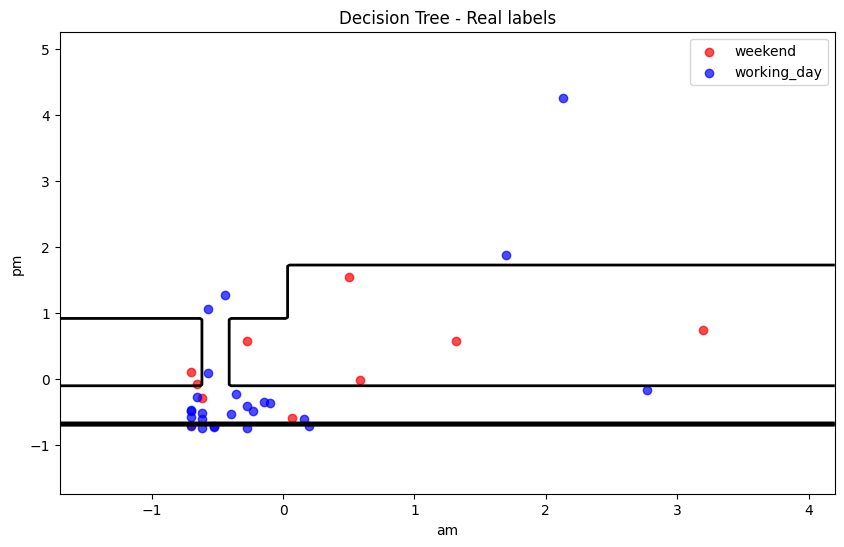

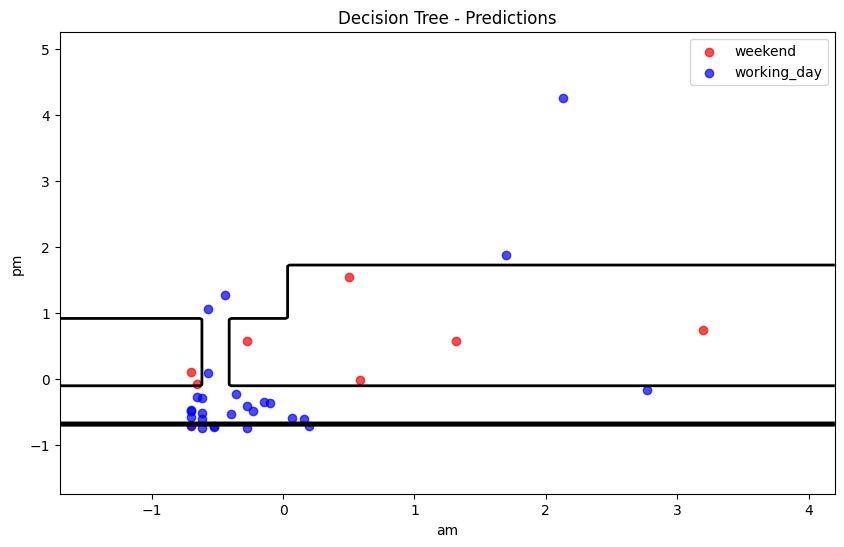

In [9]:
# Baseline tree max_depth=4
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_scaled, y)

plot_decision_boundary(tree, X_scaled, y, 'Decision Tree - Real labels')
plot_decision_boundary(tree, X_scaled, tree.predict(X_scaled), 'Decision Tree - Predictions')

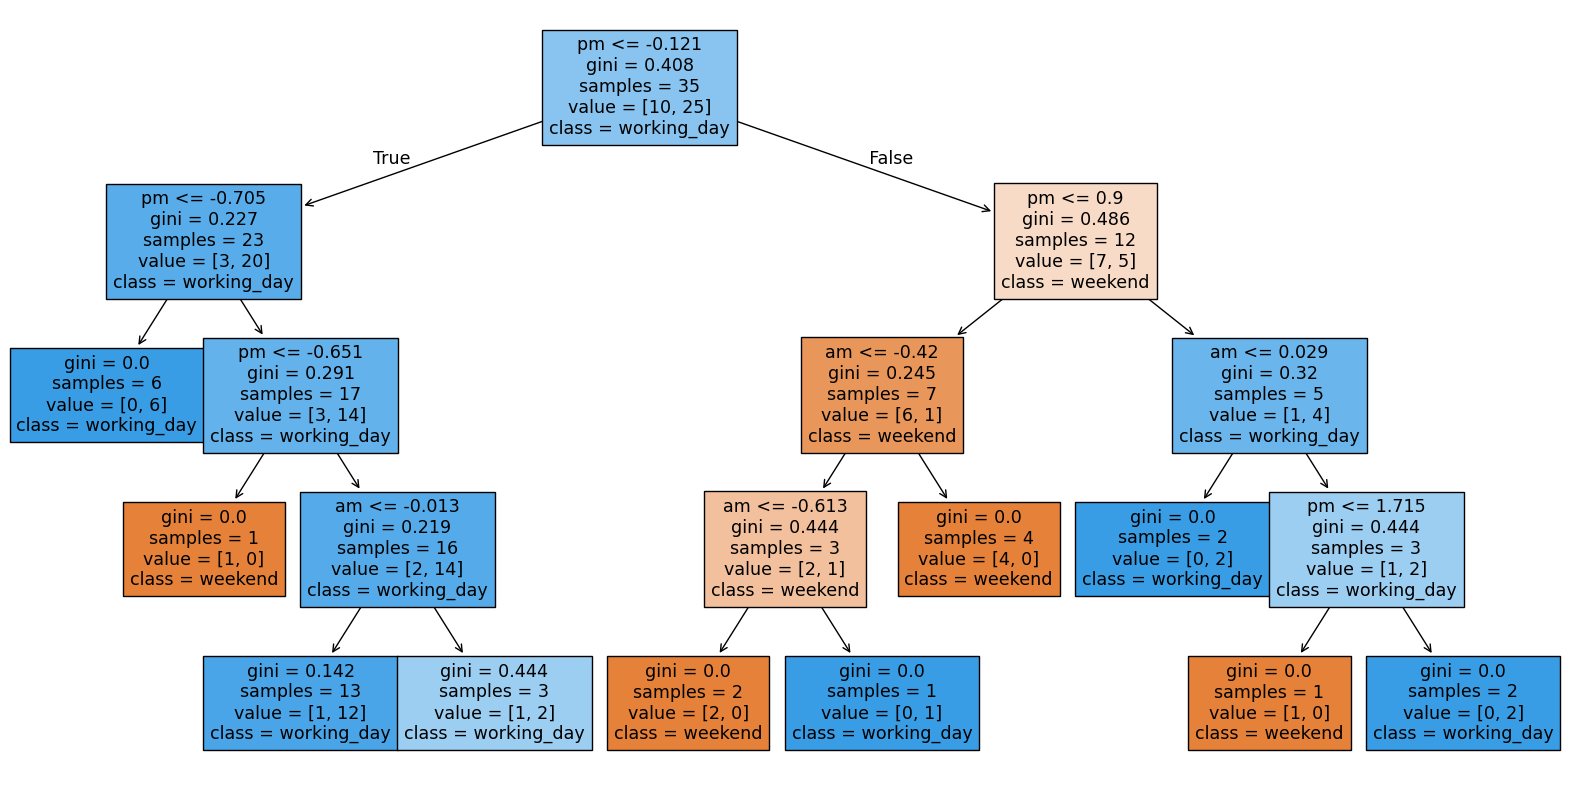

In [10]:
# Visualize the tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(tree, feature_names=['am', 'pm'],
          class_names=tree.classes_, filled=True, ax=ax)
plt.show()

In [11]:
# Count leaves that label as working_day
n_nodes = tree.tree_.node_count
children_left = tree.tree_.children_left
children_right = tree.tree_.children_right
values = tree.tree_.value
classes = tree.classes_

working_day_leaves = 0
for i in range(n_nodes):
    is_leaf = children_left[i] == -1 and children_right[i] == -1
    if is_leaf:
        predicted_class = classes[np.argmax(values[i])]
        if predicted_class == 'working_day':
            working_day_leaves += 1

print(f'Number of leaves labeling days as working_day: {working_day_leaves}')

Number of leaves labeling days as working_day: 6


Number of leaves labeling days as working_day: 6